In [1]:
import numpy as np
import math
from matplotlib import pyplot as plt
import sys
np.set_printoptions(threshold=sys.maxsize)

from src.initial_data import initial_data
from src.integrators import solve_ODE
from src.error import wass_2_approx

# Configuration


In [2]:
m = 2

h = .01
moll_eps = 4 * h**(.99)
xi_eps = 8 * h**(.99)

t_max = 1
t_step = 5 * 10**(-3)

# Parameters for random blob methods
alg = 1
num_batches = 1
ratio = 1

# Function definitions


In [3]:
# The external potential
def V(x):
    alpha = 1 / (m + 1)
    return alpha * x**2 / 2

# Gradient of velocity field
def grad_V(x):
    alpha = 1 / (m + 1)
    return alpha * x
        
# Distribution of our initial data
def rho_0(x):
    return psi_mod(sigma(), x)

tau = 0.0625

def sigma():
    conditions = np.array([m == 1/2, m == 3/4, m == 1, m == 2, m == 3, m == 5])
    results = np.array([-1.845, -2.030, -2.197, -2.723, -3.137, -3.807])
    return np.select(conditions, results, default = 0)
    
# Gaussian or Barenblatt
def psi(t, x):
    if m == 1:
        denom = (4 * np.pi * t)**(1 / 2)
        arg = - x**2 / (4 * t)
        return np.exp(arg) / denom

    else:
        beta = 1 / (m + 1)
        kappa = (beta / 2) * ((m - 1) / m)

        if m > 1:
            K = (math.gamma(m/(m-1)+1/2)*(kappa)**(1/2)/(math.gamma(m/(m-1))*np.pi**(1/2)))**(2*(m-1)/(m+1))
        else:
            num = np.sqrt((m + m**2) / (1 - m)) * math.gamma((m + 1) / (2 - 2*m))
            denom = math.gamma(1 / (1 - m))
            scalar = (2 * np.pi)**((2 / (m + 1)) - 1)
            power = -2 + (4 / (m + 1))
            K = scalar * (num / denom)**(power)

        posMax = K - kappa * x**2 * (t)**(-2 * beta)
        return (t)**(- beta) * np.maximum(posMax, 0)**(1 / (m - 1))

def psi_mod(t, x):
    alpha = 1 / (m + 1)
    return np.exp(alpha * t) * psi(np.exp(t) + tau, x * np.exp(alpha * t))

# 2nd derivative of Moreau-Yosida envelope
def f_double_prime_epsilon(x):
    return m * x**(m - 2)

# Exact solution
def exact(t, x):
    return psi_mod(t + sigma(), x)

# Plot


In [4]:
def xi(x):
    denom = (2 * np.pi * (xi_eps**2))**(1 / 2)
    arg = - (x**2) / (2 * (xi_eps**2))
    return np.exp(arg) / denom

def smooth(input, m_vals, part_sol):
    return np.dot(xi(input[:, None] - part_sol), m_vals)

def plot(particle_sol, m_vals, num_steps = 5):
    plt.rcParams.update({'font.size': 20})
    plt.rcParams['text.usetex'] = True
    plt.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'

    x_vals = np.arange(- 3.5, 3.5, .01)
    colors = plt.cm.viridis(np.linspace(0, 1, num_steps))
    jump_size = int(particle_sol.shape[0] / (num_steps - 1))

    # Plot particles BEFORE final time
    for i in range(num_steps - 1):
        y_vals = smooth(x_vals, m_vals, particle_sol[i * jump_size])
        lab = rf'$t = {round(t_max * (jump_size / particle_sol.shape[0]) * i, 3)}$'
        plt.plot(x_vals, y_vals, '--', linewidth=5, label = lab, color = colors[i])

    # Plot final step
    y_vals = smooth(x_vals, m_vals, particle_sol[-1])
    lab = rf'$t = {round(t_max, 2)}$'
    plt.plot(x_vals, y_vals, '--', linewidth=5, label = lab, color = colors[-1])

    # Plot exact solutions
    for t in range(num_steps):
        y_vals = exact(t * (t_max / (num_steps - 1)), x_vals)
        plt.plot(x_vals, y_vals, color = 'black', linewidth=1.5)

    plt.title(r"$V(x) = \frac{x^2}{6}$", pad=15)
    plt.xlabel("Position")
    plt.legend(loc='upper right')
    plt.ylim(0, .35)
    plt.xlim(-3, 7)



# Main method


N = 521.
--- 0.7164690494537354 seconds ---


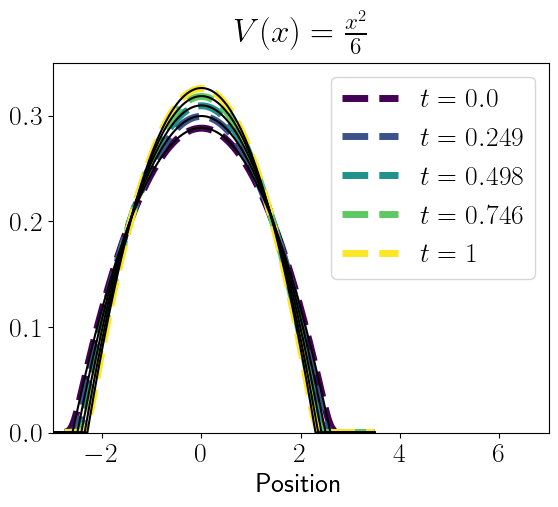

Error = 0.0030246809515631187.


In [5]:
x0, m_vals = initial_data(rho_0, 10, h)
part_sol, runtime = solve_ODE(x0, m_vals, alg, ratio, num_batches, moll_eps, f_double_prime_epsilon, grad_V, t_step, t_max)
plot(part_sol, m_vals, num_steps=5)
plt.show()

def func(x):
    return exact(t_max, x)
error = wass_2_approx(part_sol[-1], m_vals, func, 5, .005)
print("Error = " + str(error) + ".")